# 03_model_training — Обучение моделей

**Цель ноутбука:**  
Обучить бинарные классификаторы на основе CatBoost для предсказания инцидентов ИБ.
Модели обучаются раздельно для каждого сегмента (infrastructure_cluster × threat_cluster)
и для двух горизонтов прогнозирования: 24 часа и 7 дней.

**Архитектура:**

```
dataset_features.parquet
        ↓
[Для каждого сегмента (infra × threat)]
        ↓
  Временной split (70% train / 15% val / 15% test)
        ↓
  CatBoostClassifier (scale_pos_weight для дисбаланса)
        ↓
  Оценка: ROC-AUC, PR-AUC, F1
        ↓
  Сохранение моделей + метаданных
```

**Входные файлы:**
- `data/interim/dataset_features.parquet`
- `data/interim/feature_meta.json`

**Выходные файлы:**
- `mvp/models/24h/<infra>_<threat>.cbm` — модели для 24-часового горизонта
- `mvp/models/7d/<infra>_<threat>.cbm` — модели для 7-дневного горизонта
- `mvp/models/results_24h.csv` — метрики качества
- `mvp/models/results_7d.csv` — метрики качества


## 1. Установка зависимостей

In [1]:
!pip install catboost -q


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import warnings
warnings.filterwarnings('ignore')

import json
import numpy as np
import pandas as pd
from pathlib import Path

import catboost as cb
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    f1_score, classification_report, confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (12, 5)

print("Все библиотеки загружены")

Все библиотеки загружены


## 2. Загрузка данных и метаданных признаков

In [3]:
base_path = Path('..')
data_dir = base_path / 'data' / 'interim'

# Загружаем датасет с признаками
dataset_model = pd.read_parquet(data_dir / 'dataset_features.parquet')

# Загружаем список признаков (создан в 02_feature_engineering.ipynb)
with open(data_dir / 'feature_meta.json', 'r') as f:
    meta = json.load(f)

feature_cols = meta['feature_cols']
cat_features = meta['cat_features']
target_cols = meta['target_cols']

print(f"Датасет: {dataset_model.shape}")
print(f"Признаков: {len(feature_cols)}")
print(f"Категориальных: {len(cat_features)}")
print(f"Целевые переменные: {target_cols}")
print(f"\nРаспределение целевых переменных:")
for t in target_cols:
    print(f"  {t}: {dataset_model[t].mean():.4f} positives")

Датасет: (26112, 44)
Признаков: 14
Категориальных: 3
Целевые переменные: ['target_next_24h', 'target_next_7d']

Распределение целевых переменных:
  target_next_24h: 0.0708 positives
  target_next_7d: 0.4003 positives


## 3. Вспомогательные функции

### `add_rolling` — скользящие признаки

Функция добавляет rolling-признаки к произвольному датафрейму.
Используется отдельно для train/val/test, чтобы избежать leakage между частями.


In [4]:
def add_rolling(df_part: pd.DataFrame) -> pd.DataFrame:
    """
    Добавляет скользящие признаки к датафрейму сегмента.

    Важно: df_part должен быть отсортирован по дате.
    Функция применяется к каждому split'у отдельно.

    Признаки:
        inc_3d_sum, inc_7d_sum, inc_30d_sum — скользящие суммы инцидентов (3/7/30 дней)
        succ_7d_sum, succ_30d_sum — скользящие суммы успешных атак
        had_incident_prev_1d/3d/7d — бинарные флаги
    """
    df_part = df_part.copy()
    grp = df_part.groupby(['infrastructure_cluster', 'threat_cluster'])

    for window, name in [(3, 'inc_3d_sum'), (7, 'inc_7d_sum'), (30, 'inc_30d_sum')]:
        df_part[name] = (
            grp['incidents_count_day']
            .shift(1)
            .rolling(window, min_periods=1)
            .sum()
            .reset_index(drop=True)
            .fillna(0)
        )

    for window, name in [(7, 'succ_7d_sum'), (30, 'succ_30d_sum')]:
        df_part[name] = (
            grp['success_count_day']
            .shift(1)
            .rolling(window, min_periods=1)
            .sum()
            .reset_index(drop=True)
            .fillna(0)
        )

    df_part['had_incident_prev_1d'] = (df_part['lag_inc_1d'] > 0).astype(int)
    df_part['had_incident_prev_3d'] = (df_part['inc_3d_sum'] > 0).astype(int)
    df_part['had_incident_prev_7d'] = (df_part['inc_7d_sum'] > 0).astype(int)

    return df_part


print("Функция add_rolling определена")

Функция add_rolling определена


## 4. Функция обучения по сегментам

### Логика сегментированного обучения

Для каждой пары (infrastructure_cluster, threat_cluster) обучается своя модель.

**Почему?**  
Паттерны атак принципиально разные для:
- IT-компаний vs промышленных предприятий
- Malware-атак vs DDoS-атак

Единая модель «усредняла» бы эти паттерны и теряла бы точность.

### Временной split

```
|<------ 70% train ------>|<-- 15% val -->|<-- 15% test -->|
                         ↑               ↑
                      train_end        val_end
```

Строго хронологический (no shuffle) — иначе утечка данных из будущего в прошлое.

### Работа с дисбалансом классов

Инциденты — редкое событие (10-30% дней). Используем `scale_pos_weight`:

```
scale_pos_weight = n_negative / n_positive
```

Это штрафует модель сильнее за пропуск положительного класса.


In [5]:
def train_binary_models_by_segments(
    data: pd.DataFrame,
    feature_cols: list,
    target_col: str,
    cat_features: list,
    min_rows: int = 120,
    min_positive: int = 10,
    verbose: bool = True
) -> tuple:
    """
    Обучает отдельную CatBoost-модель для каждого сегмента (infra × threat).

    Параметры:
    ----------
    data : pd.DataFrame
        Датасет с признаками и целевой переменной.
    feature_cols : list
        Список имён признаков.
    target_col : str
        Имя целевой переменной ('target_next_24h' или 'target_next_7d').
    cat_features : list
        Список категориальных признаков для CatBoost.
    min_rows : int
        Минимальное количество строк для обучения сегмента (по умолчанию 120).
    min_positive : int
        Минимальное количество положительных примеров (по умолчанию 10).
    verbose : bool
        Выводить ли лог обучения.

    Возвращает:
    ----------
    models : dict
        Словарь {(infra, threat): CatBoostClassifier}
    results_df : pd.DataFrame
        Таблица метрик по всем сегментам.
    """
    models = {}
    results = []

    # Уникальные значения кластеров
    infra_values = sorted(data['infrastructure_cluster'].astype(str).unique())
    threat_values = sorted(data['threat_cluster'].dropna().astype(int).unique())

    for infra_value in infra_values:
        for threat_value in threat_values:

            # Извлекаем данные сегмента
            part = data[
                (data['infrastructure_cluster'].astype(str) == str(infra_value)) &
                (data['threat_cluster'].astype(int) == int(threat_value))
            ].copy()

            n_rows = len(part)
            n_pos = part[target_col].sum() if n_rows > 0 else 0
            pos_rate = n_pos / n_rows if n_rows > 0 else np.nan

            seg_label = f"infra={infra_value}, threat={threat_value}"

            if verbose:
                print(f"\n{'='*80}")
                print(f"Сегмент: {seg_label} | target={target_col}")
                print(f"  Строк: {n_rows} | Positives: {n_pos} ({pos_rate:.4f})")

            # Проверка минимальных требований к сегменту
            if n_rows < min_rows:
                if verbose:
                    print(f"  ⚠️ ПРОПУСК: слишком мало строк (нужно >= {min_rows})")
                continue

            if n_pos < min_positive:
                if verbose:
                    print(f"  ⚠️ ПРОПУСК: мало положительных примеров (нужно >= {min_positive})")
                continue

            if n_pos == n_rows:
                if verbose:
                    print(f"  ⚠️ ПРОПУСК: все примеры положительные (один класс)")
                continue

            # Сортируем по дате — критически важно для временного split'а
            part = part.sort_values('date').reset_index(drop=True)

            unique_dates = np.array(sorted(part['date'].unique()))
            n_dates = len(unique_dates)

            if n_dates < 30:
                if verbose:
                    print(f"  ⚠️ ПРОПУСК: мало уникальных дат ({n_dates} < 30)")
                continue

            # --- Временной split: 70% / 15% / 15% ---
            train_end = int(n_dates * 0.70)
            val_end   = int(n_dates * 0.85)

            train_dates = unique_dates[:train_end]
            val_dates   = unique_dates[train_end:val_end]
            test_dates  = unique_dates[val_end:]

            train_df = part[part['date'].isin(train_dates)].copy()
            val_df   = part[part['date'].isin(val_dates)].copy()
            test_df  = part[part['date'].isin(test_dates)].copy()

            # Добавляем rolling-признаки к каждому split'у независимо
            # (чтобы rolling не «видело» данные из val при обучении)
            train_df = add_rolling(train_df)
            val_df   = add_rolling(val_df)
            test_df  = add_rolling(test_df)

            if verbose:
                print(f"  Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

            # Формируем матрицы признаков и целевые векторы
            X_train = train_df[feature_cols].copy()
            y_train = train_df[target_col].copy()
            X_val   = val_df[feature_cols].copy()
            y_val   = val_df[target_col].copy()
            X_test  = test_df[feature_cols].copy()
            y_test  = test_df[target_col].copy()

            # Категориальные признаки → строки (требование CatBoost)
            local_cat = [c for c in cat_features if c in feature_cols]
            for col in local_cat:
                X_train[col] = X_train[col].astype(str)
                X_val[col]   = X_val[col].astype(str)
                X_test[col]  = X_test[col].astype(str)

            # Обёртки CatBoost Pool
            train_pool = cb.Pool(X_train, y_train, cat_features=local_cat)
            val_pool   = cb.Pool(X_val,   y_val,   cat_features=local_cat)

            # Вес для компенсации дисбаланса классов
            n_neg = (y_train == 0).sum()
            n_pos_train = (y_train == 1).sum()
            scale_pos = n_neg / max(n_pos_train, 1)

            # --- Обучение CatBoostClassifier ---
            model = cb.CatBoostClassifier(
                iterations=500,           # число деревьев
                learning_rate=0.05,       # шаг градиентного спуска
                depth=6,                  # глубина дерева
                l2_leaf_reg=3,            # L2-регуляризация листьев
                scale_pos_weight=scale_pos,  # компенсация дисбаланса
                eval_metric='AUC',        # метрика для early stopping
                early_stopping_rounds=50, # останавливаемся, если нет улучшения
                random_seed=42,
                verbose=0                 # отключаем вывод CatBoost
            )

            model.fit(
                train_pool,
                eval_set=val_pool,
                use_best_model=True       # берём модель на лучшей итерации по val
            )

            # --- Оценка качества ---
            # Вероятности для ROC-AUC и PR-AUC
            val_proba  = model.predict_proba(X_val)[:, 1]
            test_proba = model.predict_proba(X_test)[:, 1]

            # Бинарные предсказания (threshold = 0.5)
            val_pred  = (val_proba  > 0.5).astype(int)
            test_pred = (test_proba > 0.5).astype(int)

            val_roc  = roc_auc_score(y_val, val_proba)   if y_val.nunique() > 1 else np.nan
            val_pr   = average_precision_score(y_val, val_proba) if y_val.nunique() > 1 else np.nan
            val_f1   = f1_score(y_val, val_pred, zero_division=0)

            test_roc = roc_auc_score(y_test, test_proba)  if y_test.nunique() > 1 else np.nan
            test_pr  = average_precision_score(y_test, test_proba) if y_test.nunique() > 1 else np.nan
            test_f1  = f1_score(y_test, test_pred, zero_division=0)

            if verbose:
                print(f"  Val:  ROC-AUC={val_roc:.4f}  PR-AUC={val_pr:.4f}  F1={val_f1:.4f}")
                print(f"  Test: ROC-AUC={test_roc:.4f} PR-AUC={test_pr:.4f} F1={test_f1:.4f}")

            # Сохраняем модель и результаты
            models[(str(infra_value), int(threat_value))] = model
            results.append({
                'infrastructure_cluster': infra_value,
                'threat_cluster': threat_value,
                'target': target_col,
                'n_rows': n_rows,
                'n_positive': n_pos,
                'pos_rate': round(pos_rate, 4),
                'train_size': len(train_df),
                'val_size': len(val_df),
                'test_size': len(test_df),
                'val_roc_auc': round(val_roc, 4) if not np.isnan(val_roc) else None,
                'val_pr_auc': round(val_pr, 4) if not np.isnan(val_pr) else None,
                'val_f1': round(val_f1, 4),
                'test_roc_auc': round(test_roc, 4) if not np.isnan(test_roc) else None,
                'test_pr_auc': round(test_pr, 4) if not np.isnan(test_pr) else None,
                'test_f1': round(test_f1, 4),
                'best_iteration': model.get_best_iteration()
            })

    results_df = pd.DataFrame(results)
    return models, results_df


print("Функция train_binary_models_by_segments определена")

Функция train_binary_models_by_segments определена


## 5. Обучение моделей: горизонт 24 часа

Предсказываем: **будет ли инцидент завтра?**

Это наиболее оперативный горизонт — актуален для daily-мониторинга и оперативных оповещений.


In [6]:
print("Начинаем обучение моделей для горизонта 24 часа...")
print(f"Всего сегментов для обхода: {dataset_model['infrastructure_cluster'].nunique()} × {dataset_model['threat_cluster'].nunique()}")

models_24h, results_24h = train_binary_models_by_segments(
    data=dataset_model,
    feature_cols=feature_cols,
    target_col='target_next_24h',
    cat_features=cat_features,
    min_rows=120,
    min_positive=10,
    verbose=True
)

print(f"\n{'='*80}")
print(f"Обучено моделей: {len(models_24h)}")
print(f"\nТаблица результатов (по убыванию PR-AUC):")
display(results_24h.sort_values('test_pr_auc', ascending=False).round(4))

Начинаем обучение моделей для горизонта 24 часа...
Всего сегментов для обхода: 4 × 6

Сегмент: infra=1, threat=1 | target=target_next_24h
  Строк: 1088 | Positives: 64 (0.0588)
  Train: 761 | Val: 163 | Test: 164
  Val:  ROC-AUC=0.7856  PR-AUC=0.2227  F1=0.2524
  Test: ROC-AUC=0.5526 PR-AUC=0.0811 F1=0.1165

Сегмент: infra=1, threat=2 | target=target_next_24h
  Строк: 1088 | Positives: 69 (0.0634)
  Train: 761 | Val: 163 | Test: 164
  Val:  ROC-AUC=0.4439  PR-AUC=0.0856  F1=0.1319
  Test: ROC-AUC=0.4166 PR-AUC=0.0622 F1=0.0690

Сегмент: infra=1, threat=3 | target=target_next_24h
  Строк: 1088 | Positives: 66 (0.0607)
  Train: 761 | Val: 163 | Test: 164
  Val:  ROC-AUC=0.5020  PR-AUC=0.0741  F1=0.0800
  Test: ROC-AUC=0.5157 PR-AUC=0.0770 F1=0.0000

Сегмент: infra=1, threat=4 | target=target_next_24h
  Строк: 1088 | Positives: 90 (0.0827)
  Train: 761 | Val: 163 | Test: 164
  Val:  ROC-AUC=0.6123  PR-AUC=0.1193  F1=0.2000
  Test: ROC-AUC=0.4753 PR-AUC=0.1220 F1=0.1034

Сегмент: infra=1, 

,infrastructure_cluster,threat_cluster,target,n_rows,n_positive,pos_rate,train_size,val_size,test_size,val_roc_auc,val_pr_auc,val_f1,test_roc_auc,test_pr_auc,test_f1,best_iteration
13,3,2,target_next_24h,1088,91,0.0836,761,163,164,0.5199,0.0853,0.0000,0.5067,0.1769,0.1176,141
21,4,4,target_next_24h,1088,81,0.0744,761,163,164,0.6269,0.1443,0.2059,0.7045,0.1559,0.1724,8
6,2,1,target_next_24h,1088,79,0.0726,761,163,164,0.4892,0.0917,0.1026,0.5822,0.1460,0.2105,71
3,1,4,target_next_24h,1088,90,0.0827,761,163,164,0.6123,0.1193,0.2000,0.4753,0.1220,0.1034,5
9,2,4,target_next_24h,1088,113,0.1039,761,163,164,0.5043,0.0948,0.1538,0.4656,0.1147,0.1148,2
16,3,5,target_next_24h,1088,76,0.0699,761,163,164,0.5597,0.0585,0.0656,0.5043,0.1079,0.1538,32
10,2,5,target_next_24h,1088,87,0.0800,761,163,164,0.7039,0.1475,0.1463,0.5126,0.0998,0.1429,20
14,3,3,target_next_24h,1088,82,0.0754,761,163,164,0.5923,0.1193,0.1803,0.5601,0.0951,0.1513,1
11,2,6,target_next_24h,1088,64,0.0588,761,163,164,0.6532,0.2628,0.2308,0.4902,0.0930,0.1111,207
20,4,3,target_next_24h,1088,69,0.0634,761,163,164,0.5259,0.0407,0.0000,0.4497,0.0930,0.0870,2


## 6. Обучение моделей: горизонт 7 дней

Предсказываем: **будет ли инцидент в течение следующей недели?**

Горизонт 7 дней актуален для еженедельного планирования защитных мероприятий.
Обычно положительных примеров больше → задача проще, но модель должна быть устойчивее.


In [7]:
print("Начинаем обучение моделей для горизонта 7 дней...")

models_7d, results_7d = train_binary_models_by_segments(
    data=dataset_model,
    feature_cols=feature_cols,
    target_col='target_next_7d',
    cat_features=cat_features,
    min_rows=120,
    min_positive=10,
    verbose=True
)

print(f"\n{'='*80}")
print(f"Обучено моделей: {len(models_7d)}")
print(f"\nТаблица результатов (по убыванию PR-AUC):")
display(results_7d.sort_values('test_pr_auc', ascending=False).round(4))

Начинаем обучение моделей для горизонта 7 дней...

Сегмент: infra=1, threat=1 | target=target_next_7d
  Строк: 1088 | Positives: 364 (0.3346)
  Train: 761 | Val: 163 | Test: 164
  Val:  ROC-AUC=0.8048  PR-AUC=0.7902  F1=0.7007
  Test: ROC-AUC=0.4806 PR-AUC=0.3597 F1=0.1867

Сегмент: infra=1, threat=2 | target=target_next_7d
  Строк: 1088 | Positives: 409 (0.3759)
  Train: 761 | Val: 163 | Test: 164
  Val:  ROC-AUC=0.6015  PR-AUC=0.6265  F1=0.2569
  Test: ROC-AUC=0.6337 PR-AUC=0.3935 F1=0.0000

Сегмент: infra=1, threat=3 | target=target_next_7d
  Строк: 1088 | Positives: 415 (0.3814)
  Train: 761 | Val: 163 | Test: 164
  Val:  ROC-AUC=0.5820  PR-AUC=0.5384  F1=0.5190
  Test: ROC-AUC=0.5592 PR-AUC=0.4909 F1=0.4463

Сегмент: infra=1, threat=4 | target=target_next_7d
  Строк: 1088 | Positives: 500 (0.4596)
  Train: 761 | Val: 163 | Test: 164
  Val:  ROC-AUC=0.6273  PR-AUC=0.5753  F1=0.4966
  Test: ROC-AUC=0.4048 PR-AUC=0.2877 F1=0.4565

Сегмент: infra=1, threat=5 | target=target_next_7d
  

,infrastructure_cluster,threat_cluster,target,n_rows,n_positive,pos_rate,train_size,val_size,test_size,val_roc_auc,val_pr_auc,val_f1,test_roc_auc,test_pr_auc,test_f1,best_iteration
15,3,4,target_next_7d,1088,500,0.4596,761,163,164,0.4854,0.5425,0.4054,0.7849,0.6831,0.4605,17
12,3,1,target_next_7d,1088,381,0.3502,761,163,164,0.5769,0.2518,0.2143,0.6881,0.6462,0.5977,14
8,2,3,target_next_7d,1088,502,0.4614,761,163,164,0.6567,0.6651,0.0000,0.6044,0.6126,0.4242,14
13,3,2,target_next_7d,1088,503,0.4623,761,163,164,0.6008,0.5432,0.5333,0.5385,0.5608,0.3622,17
10,2,5,target_next_7d,1088,506,0.4651,761,163,164,0.6391,0.5605,0.4930,0.6182,0.5332,0.3725,27
6,2,1,target_next_7d,1088,481,0.4421,761,163,164,0.6779,0.5683,0.5041,0.5364,0.5195,0.5000,0
11,2,6,target_next_7d,1088,358,0.3290,761,163,164,0.4726,0.3170,0.3077,0.5424,0.5099,0.2766,21
20,4,3,target_next_7d,1088,386,0.3548,761,163,164,0.4811,0.1665,0.0000,0.4529,0.5043,0.4643,5
2,1,3,target_next_7d,1088,415,0.3814,761,163,164,0.5820,0.5384,0.5190,0.5592,0.4909,0.4463,1
18,4,1,target_next_7d,1088,404,0.3713,761,163,164,0.7957,0.4533,0.5116,0.4590,0.4623,0.5991,21


## 7. Анализ результатов обучения

Визуализируем качество моделей и понимаем, для каких сегментов модели работают лучше.


In [8]:
# Сравнительная таблица по обоим горизонтам
results_24h['horizon'] = '24h'
results_7d['horizon'] = '7d'

all_results = pd.concat([results_24h, results_7d], ignore_index=True)

# Сводная статистика
print("=== Статистика качества моделей ===\n")
for horizon in ['24h', '7d']:
    df_h = all_results[all_results['horizon'] == horizon]
    print(f"Горизонт {horizon}:")
    print(f"  Моделей обучено: {len(df_h)}")
    print(f"  ROC-AUC: mean={df_h['test_roc_auc'].mean():.4f}, "
          f"min={df_h['test_roc_auc'].min():.4f}, "
          f"max={df_h['test_roc_auc'].max():.4f}")
    print(f"  PR-AUC:  mean={df_h['test_pr_auc'].mean():.4f}, "
          f"min={df_h['test_pr_auc'].min():.4f}, "
          f"max={df_h['test_pr_auc'].max():.4f}")
    print()

=== Статистика качества моделей ===

Горизонт 24h:
  Моделей обучено: 24
  ROC-AUC: mean=0.4924, min=0.3848, max=0.7045
  PR-AUC:  mean=0.0908, min=0.0321, max=0.1769

Горизонт 7d:
  Моделей обучено: 24
  ROC-AUC: mean=0.5255, min=0.2026, max=0.7849
  PR-AUC:  mean=0.4466, min=0.2877, max=0.6831



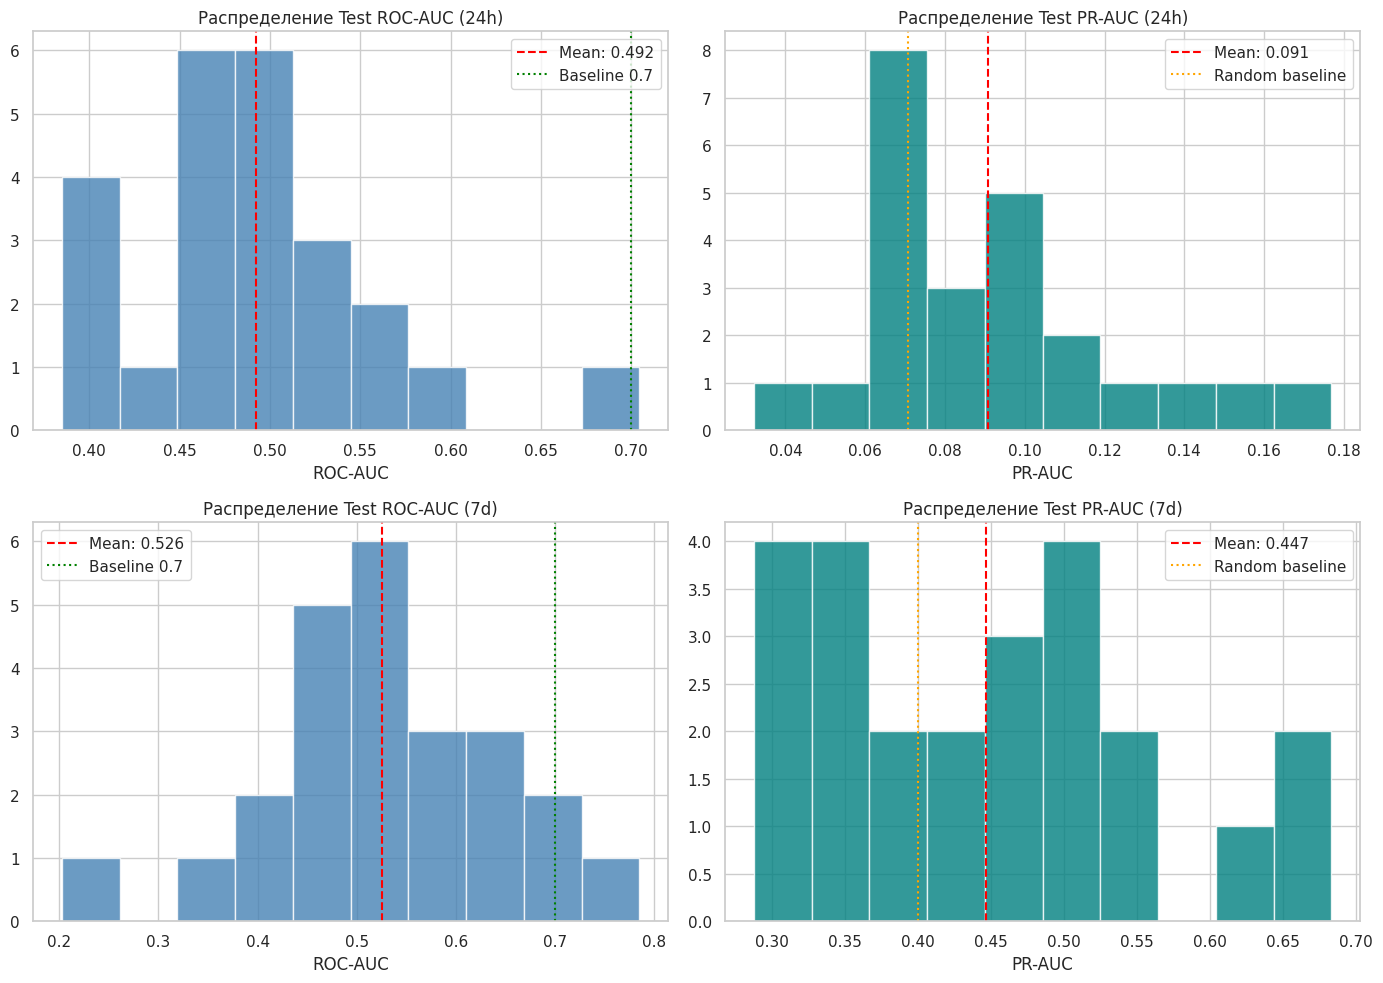

In [9]:
# Визуализация: распределение ROC-AUC и PR-AUC
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for i, horizon in enumerate(['24h', '7d']):
    df_h = all_results[all_results['horizon'] == horizon]

    # ROC-AUC
    axes[i, 0].hist(df_h['test_roc_auc'].dropna(), bins=10,
                    color='steelblue', edgecolor='white', alpha=0.8)
    axes[i, 0].axvline(df_h['test_roc_auc'].mean(), color='red',
                       linestyle='--', label=f"Mean: {df_h['test_roc_auc'].mean():.3f}")
    axes[i, 0].axvline(0.7, color='green', linestyle=':', label='Baseline 0.7')
    axes[i, 0].set_title(f'Распределение Test ROC-AUC ({horizon})')
    axes[i, 0].set_xlabel('ROC-AUC')
    axes[i, 0].legend()

    # PR-AUC
    axes[i, 1].hist(df_h['test_pr_auc'].dropna(), bins=10,
                    color='teal', edgecolor='white', alpha=0.8)
    axes[i, 1].axvline(df_h['test_pr_auc'].mean(), color='red',
                       linestyle='--', label=f"Mean: {df_h['test_pr_auc'].mean():.3f}")
    axes[i, 1].axvline(df_h['pos_rate'].mean(), color='orange',
                       linestyle=':', label='Random baseline')
    axes[i, 1].set_title(f'Распределение Test PR-AUC ({horizon})')
    axes[i, 1].set_xlabel('PR-AUC')
    axes[i, 1].legend()

plt.tight_layout()
plt.show()

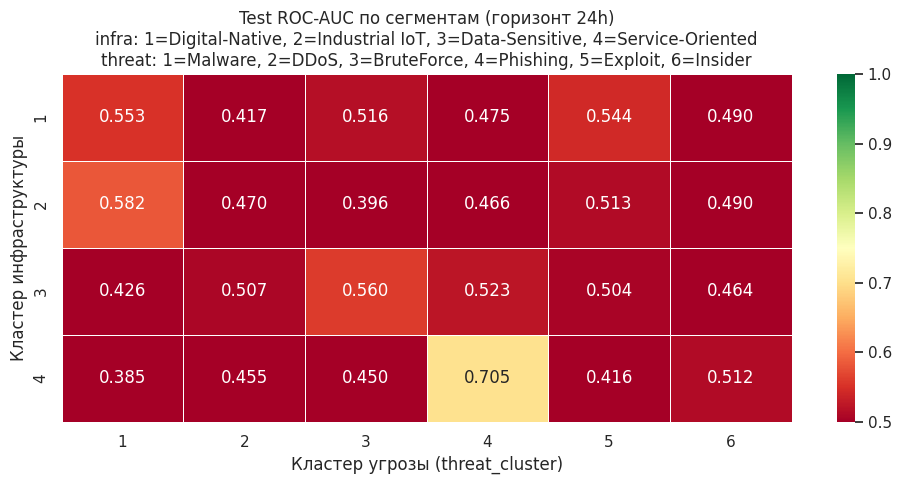

In [10]:
# Heatmap качества по сегментам (ROC-AUC, горизонт 24h)
pivot_roc = results_24h.pivot(
    index='infrastructure_cluster',
    columns='threat_cluster',
    values='test_roc_auc'
)

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(
    pivot_roc,
    annot=True,
    fmt='.3f',
    cmap='RdYlGn',
    vmin=0.5, vmax=1.0,
    ax=ax,
    linewidths=0.5,
    mask=pivot_roc.isna()
)
ax.set_title('Test ROC-AUC по сегментам (горизонт 24h)\n'
             'infra: 1=Digital-Native, 2=Industrial IoT, 3=Data-Sensitive, 4=Service-Oriented\n'
             'threat: 1=Malware, 2=DDoS, 3=BruteForce, 4=Phishing, 5=Exploit, 6=Insider')
ax.set_xlabel('Кластер угрозы (threat_cluster)')
ax.set_ylabel('Кластер инфраструктуры')
plt.tight_layout()
plt.show()

## 8. Важность признаков

Анализируем, какие признаки наиболее значимы для предсказания.
Используем встроенный механизм важности CatBoost (SHAP-style и feature_importances_).


Важность признаков для сегмента infra=1, threat=1:


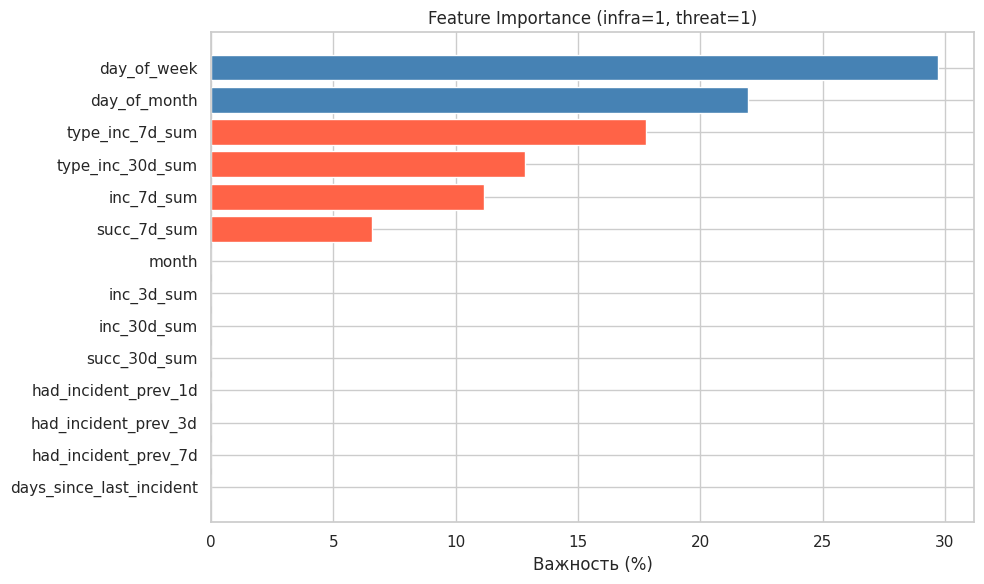


Топ-10 признаков:


,feature,importance
0,day_of_week,29.704227
1,day_of_month,21.944573
12,type_inc_7d_sum,17.796817
13,type_inc_30d_sum,12.827712
4,inc_7d_sum,11.134519
6,succ_7d_sum,6.592152
2,month,0.000000
3,inc_3d_sum,0.000000
5,inc_30d_sum,0.000000
7,succ_30d_sum,0.000000


In [11]:
# Берём любую обученную модель для анализа важности
if models_24h:
    sample_key = list(models_24h.keys())[0]
    sample_model = models_24h[sample_key]

    # Получаем важности признаков
    feature_importance = pd.DataFrame({
        'feature': feature_cols,
        'importance': sample_model.get_feature_importance()
    }).sort_values('importance', ascending=False)

    print(f"Важность признаков для сегмента infra={sample_key[0]}, threat={sample_key[1]}:")

    fig, ax = plt.subplots(figsize=(10, max(6, len(feature_cols) * 0.3)))
    colors = ['tomato' if 'lag' in f or 'rolling' in f or 'inc' in f or 'succ' in f or 'days_since' in f
              else 'steelblue' for f in feature_importance['feature']]
    ax.barh(feature_importance['feature'], feature_importance['importance'], color=colors)
    ax.invert_yaxis()
    ax.set_title(f'Feature Importance (infra={sample_key[0]}, threat={sample_key[1]})')
    ax.set_xlabel('Важность (%)')
    plt.tight_layout()
    plt.show()

    print("\nТоп-10 признаков:")
    display(feature_importance.head(10))

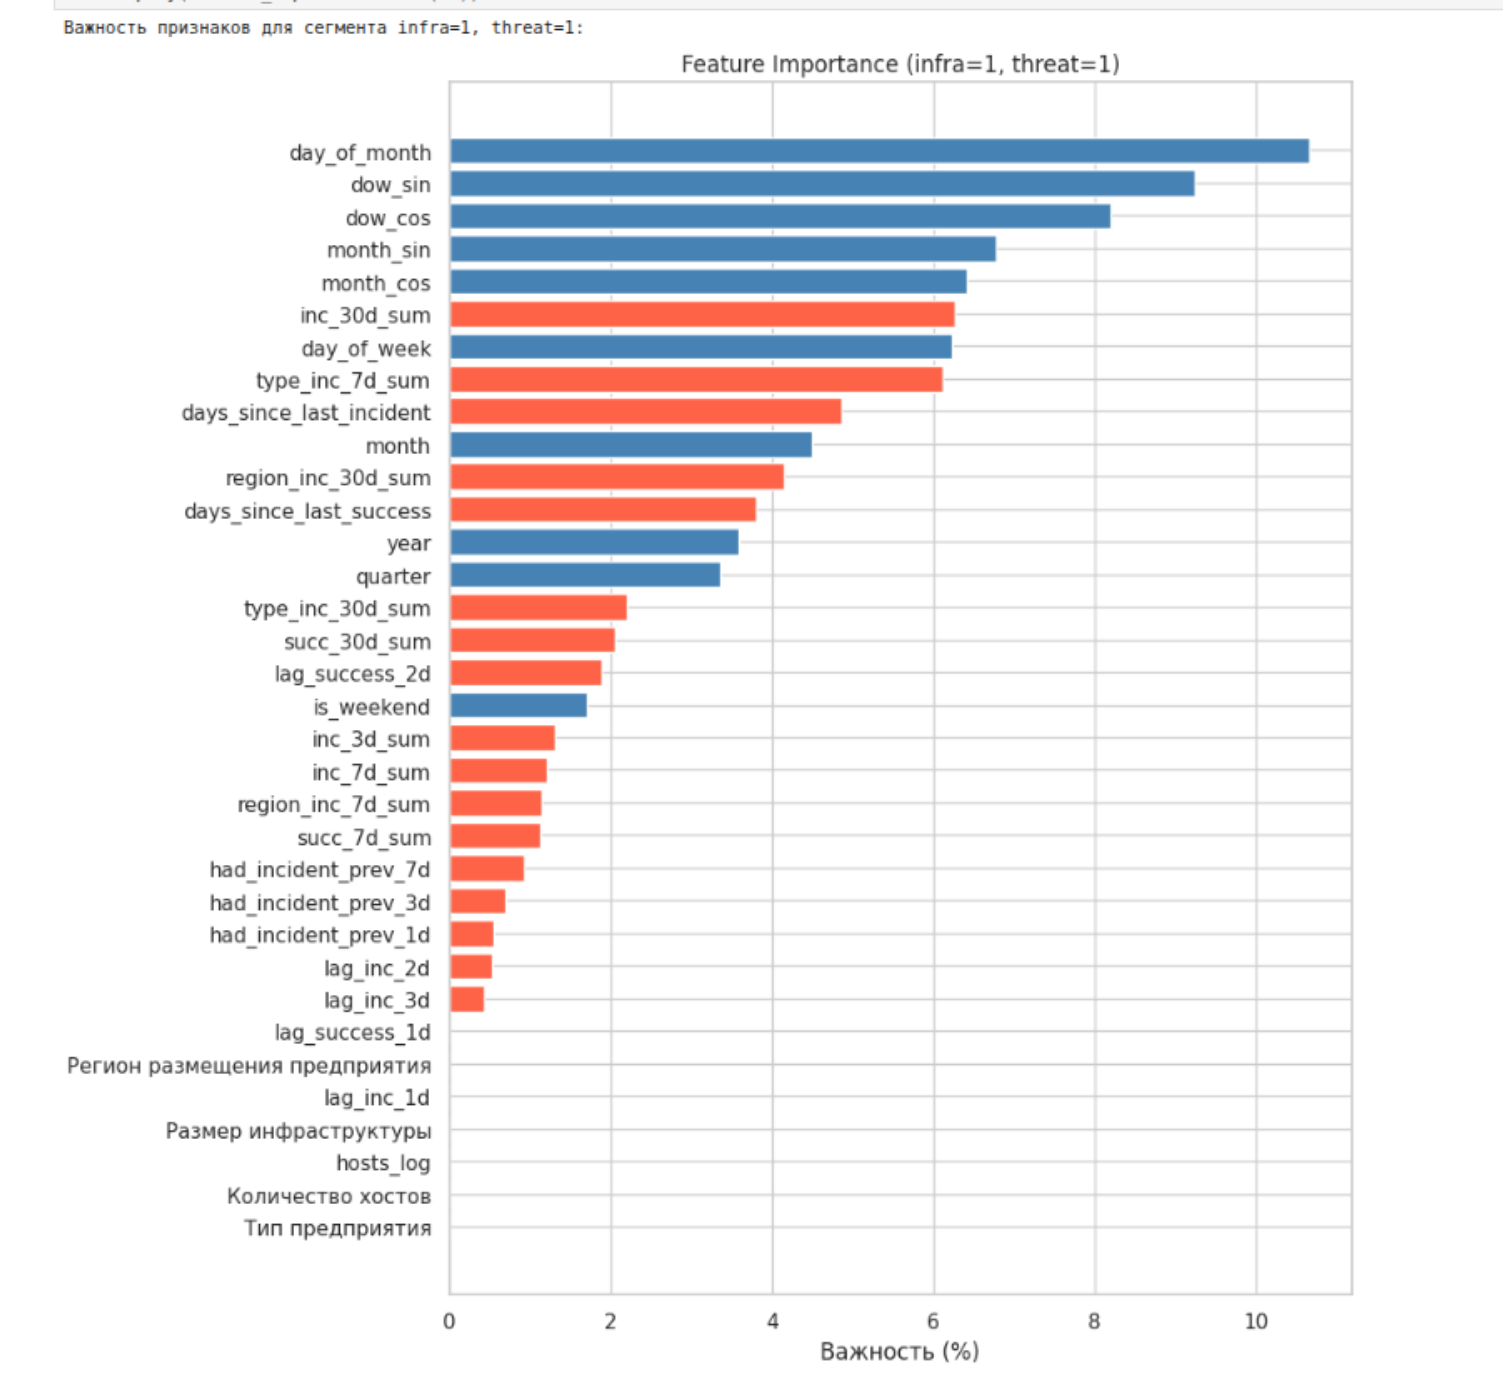

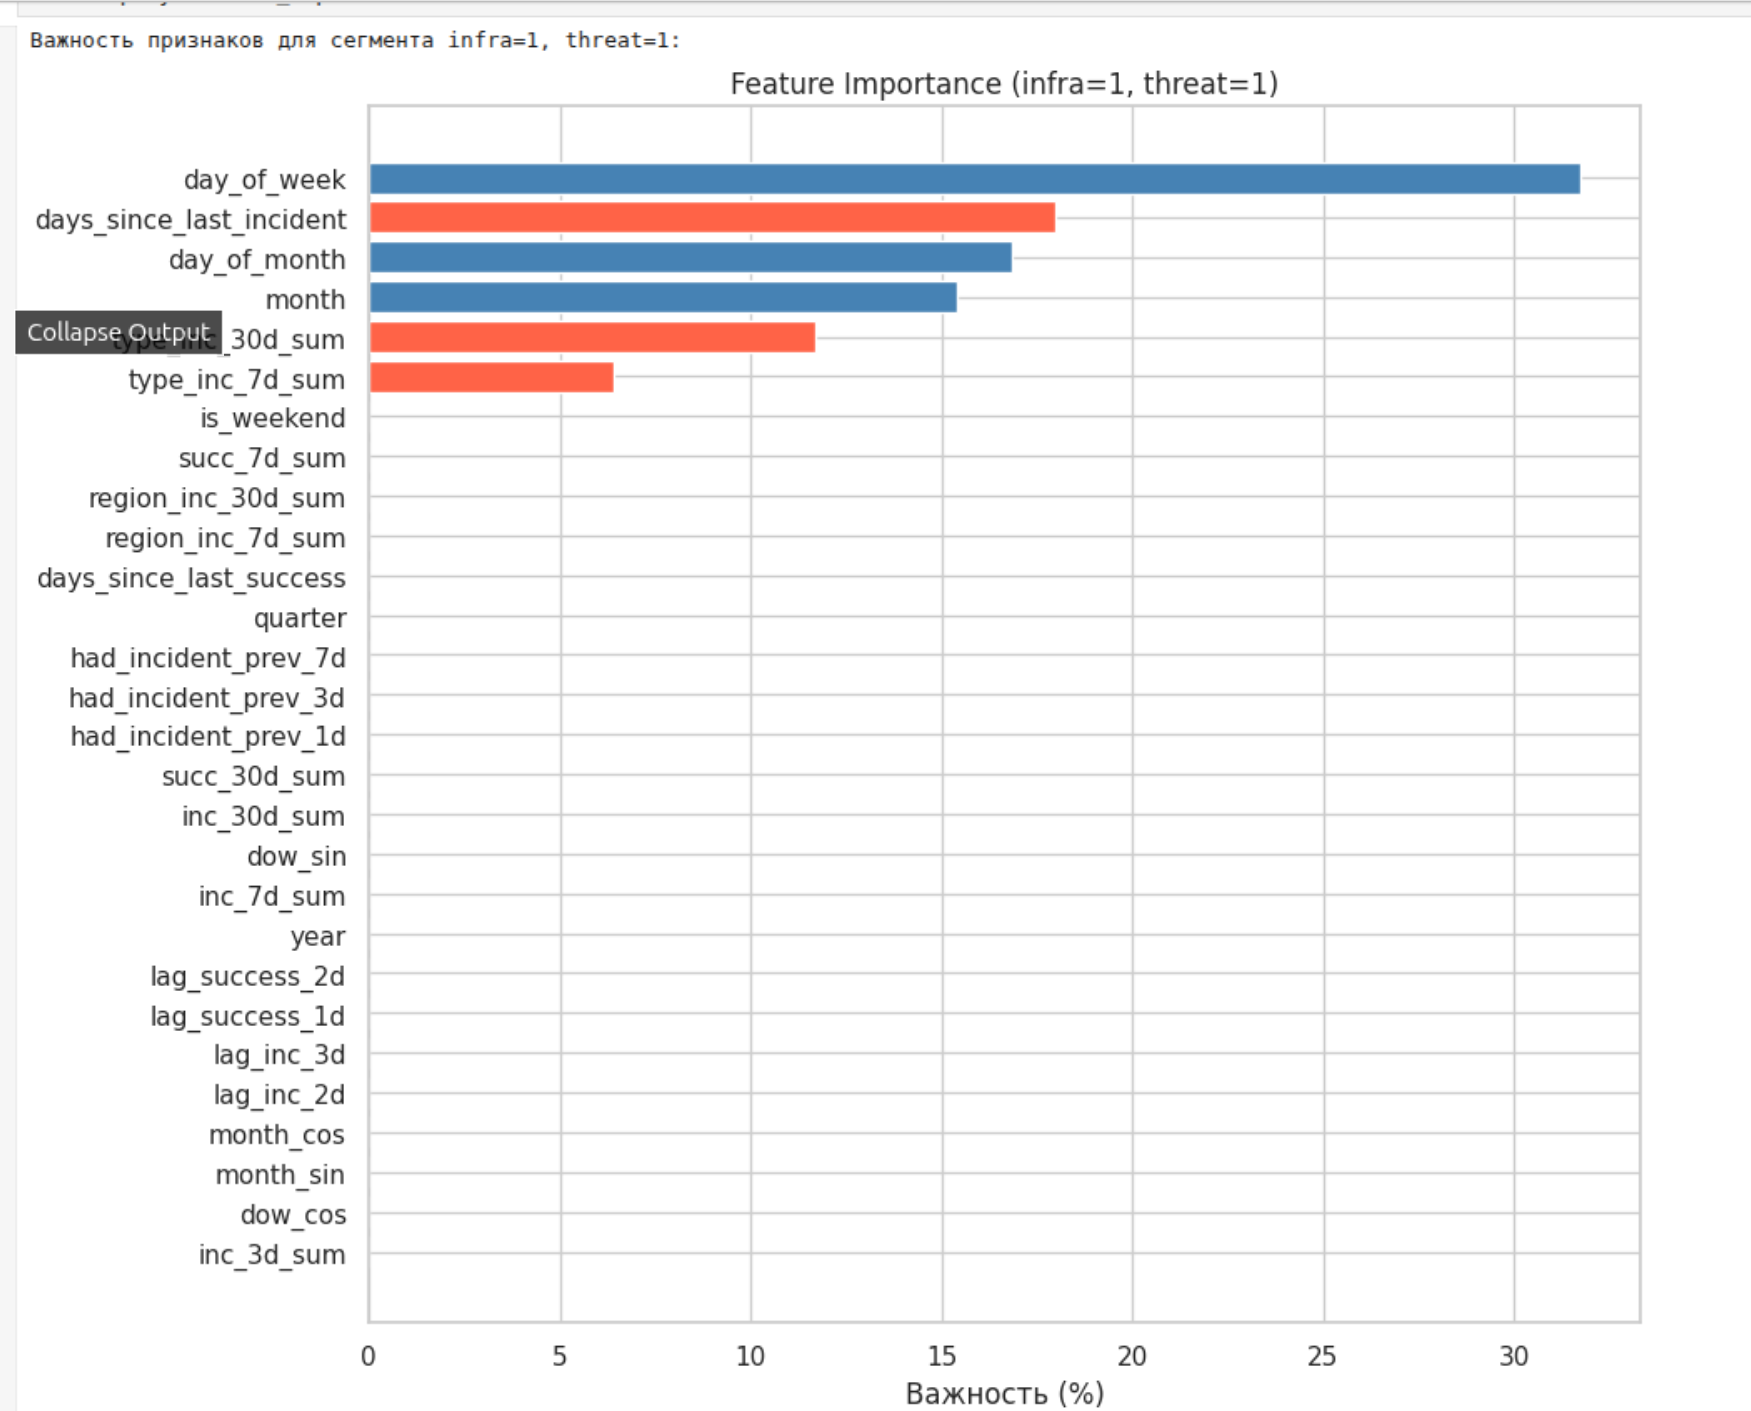

## 9. Confusion Matrix и детальный отчёт

Для наглядного понимания ошибок модели: как часто пропускаем инцидент vs. ложная тревога.

**Для задачи ИБ важнее минимизировать FN (пропущенный инцидент),
чем FP (ложная тревога).** Поэтому PR-AUC важнее, чем общая accuracy.


Оцениваем лучший сегмент: infra=4, threat=4


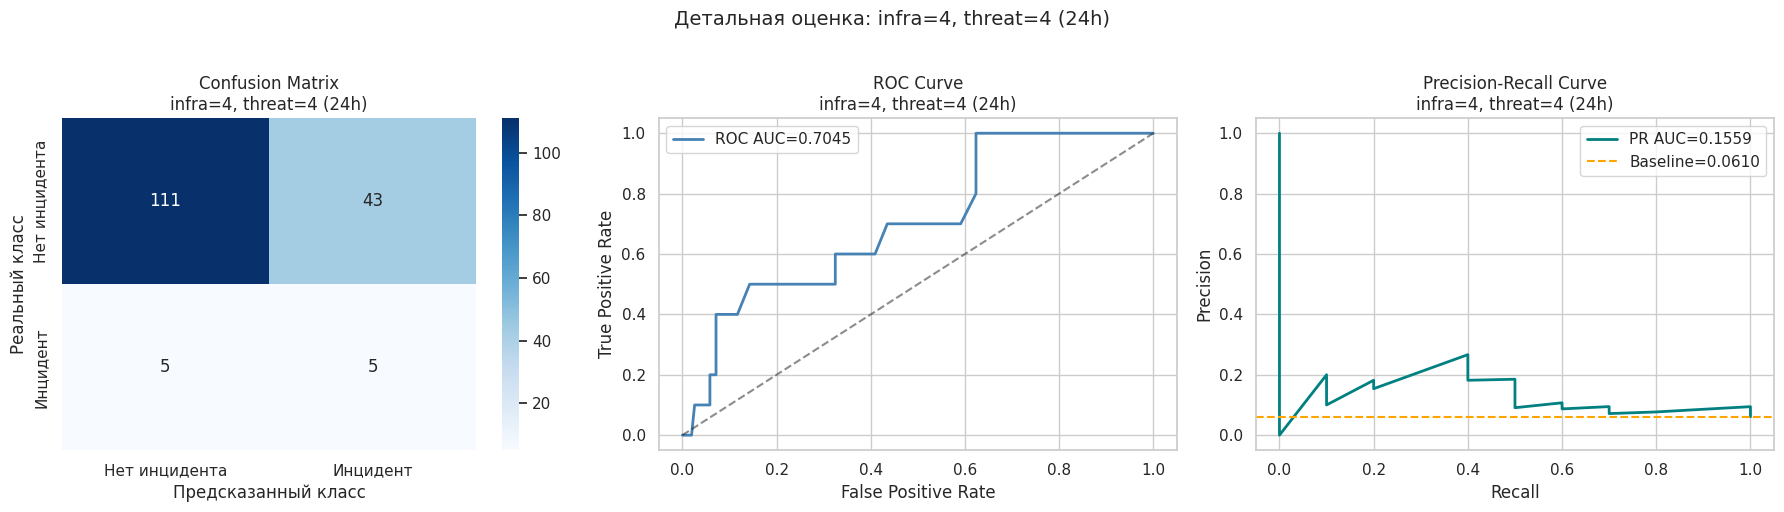


Classification Report:
               precision    recall  f1-score   support

Нет инцидента       0.96      0.72      0.82       154
     Инцидент       0.10      0.50      0.17        10

     accuracy                           0.71       164
    macro avg       0.53      0.61      0.50       164
 weighted avg       0.90      0.71      0.78       164



In [12]:
def evaluate_segment_model(model, X_test, y_test, segment_label, threshold=0.5):
    """
    Детальная оценка модели для одного сегмента:
    - Confusion matrix
    - Classification report
    - ROC и PR кривые
    """
    proba = model.predict_proba(X_test)[:, 1]
    pred = (proba > threshold).astype(int)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # 1. Confusion Matrix
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=['Нет инцидента', 'Инцидент'],
                yticklabels=['Нет инцидента', 'Инцидент'])
    axes[0].set_title(f'Confusion Matrix\n{segment_label}')
    axes[0].set_ylabel('Реальный класс')
    axes[0].set_xlabel('Предсказанный класс')

    # 2. ROC Curve
    from sklearn.metrics import roc_curve, precision_recall_curve
    fpr, tpr, _ = roc_curve(y_test, proba)
    roc_auc = roc_auc_score(y_test, proba)
    axes[1].plot(fpr, tpr, color='steelblue', lw=2, label=f'ROC AUC={roc_auc:.4f}')
    axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.5)
    axes[1].set_title(f'ROC Curve\n{segment_label}')
    axes[1].set_xlabel('False Positive Rate')
    axes[1].set_ylabel('True Positive Rate')
    axes[1].legend()

    # 3. Precision-Recall Curve
    prec, rec, _ = precision_recall_curve(y_test, proba)
    pr_auc = average_precision_score(y_test, proba)
    axes[2].plot(rec, prec, color='teal', lw=2, label=f'PR AUC={pr_auc:.4f}')
    axes[2].axhline(y_test.mean(), color='orange', linestyle='--',
                    label=f'Baseline={y_test.mean():.4f}')
    axes[2].set_title(f'Precision-Recall Curve\n{segment_label}')
    axes[2].set_xlabel('Recall')
    axes[2].set_ylabel('Precision')
    axes[2].legend()

    plt.suptitle(f'Детальная оценка: {segment_label}', y=1.02, fontsize=14)
    plt.tight_layout()
    plt.show()

    print("\nClassification Report:")
    print(classification_report(y_test, pred,
                                 target_names=['Нет инцидента', 'Инцидент'],
                                 zero_division=0))


# Пример оценки для лучшего сегмента 24h
if not results_24h.empty:
    best_seg = results_24h.dropna(subset=['test_roc_auc']).sort_values('test_roc_auc', ascending=False).iloc[0]
    infra_val = str(best_seg['infrastructure_cluster'])
    threat_val = int(best_seg['threat_cluster'])

    key = (infra_val, threat_val)
    if key in models_24h:
        print(f"Оцениваем лучший сегмент: infra={infra_val}, threat={threat_val}")

        # Воспроизводим test split для этого сегмента
        part = dataset_model[
            (dataset_model['infrastructure_cluster'].astype(str) == infra_val) &
            (dataset_model['threat_cluster'].astype(int) == threat_val)
        ].sort_values('date').reset_index(drop=True)

        unique_dates = np.array(sorted(part['date'].unique()))
        n_dates = len(unique_dates)
        val_end = int(n_dates * 0.85)
        test_dates = unique_dates[val_end:]

        test_df = add_rolling(part[part['date'].isin(test_dates)].copy())
        X_test_seg = test_df[feature_cols].copy()
        for col in cat_features:
            if col in X_test_seg.columns:
                X_test_seg[col] = X_test_seg[col].astype(str)
        y_test_seg = test_df['target_next_24h']

        evaluate_segment_model(
            models_24h[key], X_test_seg, y_test_seg,
            f"infra={infra_val}, threat={threat_val} (24h)"
        )

## 10. Сохранение моделей

Сохраняем все обученные модели в формате `.cbm` (CatBoost model).
Структура директорий:

```
mvp/
├── models/
│   ├── 24h/
│   │   ├── 1_1.cbm   # infra=1, threat=1
│   │   ├── 1_2.cbm
│   │   └── ...
│   ├── 7d/
│   │   ├── 1_1.cbm
│   │   └── ...
│   ├── results_24h.csv
│   └── results_7d.csv
└── data/
    └── dataset_features.parquet
```


In [13]:
# Создаём директории
PROJECT_ROOT = Path(".").resolve()

MVP_DIR = PROJECT_ROOT / "mvp"
MODELS_24H_DIR = MVP_DIR / "models" / "24h"
MODELS_7D_DIR  = MVP_DIR / "models" / "7d"

for path in [MODELS_24H_DIR, MODELS_7D_DIR]:
    path.mkdir(parents=True, exist_ok=True)

# Сохраняем модели 24h
for (infra, threat), model in models_24h.items():
    model_path = MODELS_24H_DIR / f"{infra}_{threat}.cbm"
    model.save_model(str(model_path))

print(f"Сохранено моделей 24h: {len(models_24h)} → {MODELS_24H_DIR}")

# Сохраняем модели 7d
for (infra, threat), model in models_7d.items():
    model_path = MODELS_7D_DIR / f"{infra}_{threat}.cbm"
    model.save_model(str(model_path))

print(f"Сохранено моделей 7d:  {len(models_7d)} → {MODELS_7D_DIR}")

# Сохраняем таблицы результатов
results_24h.to_csv(MVP_DIR / "models" / "results_24h.csv", index=False)
results_7d.to_csv(MVP_DIR / "models" / "results_7d.csv", index=False)

print(f"\nТаблицы результатов сохранены в {MVP_DIR / 'models'}")

Сохранено моделей 24h: 24 → /home/max/projects/rsm_hackathon_2026/notebooks/mvp/models/24h
Сохранено моделей 7d:  24 → /home/max/projects/rsm_hackathon_2026/notebooks/mvp/models/7d

Таблицы результатов сохранены в /home/max/projects/rsm_hackathon_2026/notebooks/mvp/models


## 11. Сохранение метаданных для деплоя

Сохраняем JSON-файл со всеми метаданными модели — необходим для корректного
применения модели в продакшн-окружении без доступа к обучающему коду.


In [14]:
import json

# Описание кластеров
cluster_info = {
    "infrastructure_clusters": {
        "1": "Digital-Native (IT, телеком, реклама, маркетинг)",
        "2": "Industrial IoT (машиностроение, металлургия, энергетика)",
        "3": "Data-Sensitive (медицина, образование, НКО)",
        "4": "Service-Oriented (розница, отели, консалтинг)"
    },
    "threat_clusters": {
        "1": "Вредоносное ПО (Malware)",
        "2": "DDoS-атаки",
        "3": "Brute Force / Подбор паролей",
        "4": "Социальная инженерия / Фишинг",
        "5": "Эксплуатация уязвимостей",
        "6": "Инсайдерские угрозы"
    }
}

# Полные метаданные деплоя
deploy_meta = {
    "version": "1.0.0",
    "description": "Модели предсказания инцидентов ИБ по сегментам инфраструктуры и типам угроз",
    "horizons": ["24h", "7d"],
    "feature_cols": feature_cols,
    "cat_features": cat_features,
    "models_24h": [f"{k[0]}_{k[1]}" for k in models_24h.keys()],
    "models_7d": [f"{k[0]}_{k[1]}" for k in models_7d.keys()],
    "cluster_info": cluster_info,
    "training_params": {
        "iterations": 500,
        "learning_rate": 0.05,
        "depth": 6,
        "early_stopping_rounds": 50,
        "min_rows_per_segment": 120,
        "min_positive_per_segment": 10,
        "split_ratio": "70/15/15 (train/val/test)"
    }
}

meta_path = MVP_DIR / "models" / "deploy_meta.json"
with open(meta_path, 'w', encoding='utf-8') as f:
    json.dump(deploy_meta, f, ensure_ascii=False, indent=2)

print(f"Метаданные деплоя сохранены: {meta_path}")
print(json.dumps(deploy_meta, ensure_ascii=False, indent=2)[:1000] + "...")

Метаданные деплоя сохранены: /home/max/projects/rsm_hackathon_2026/notebooks/mvp/models/deploy_meta.json
{
  "version": "1.0.0",
  "description": "Модели предсказания инцидентов ИБ по сегментам инфраструктуры и типам угроз",
  "horizons": [
    "24h",
    "7d"
  ],
  "feature_cols": [
    "day_of_week",
    "day_of_month",
    "month",
    "inc_3d_sum",
    "inc_7d_sum",
    "inc_30d_sum",
    "succ_7d_sum",
    "succ_30d_sum",
    "had_incident_prev_1d",
    "had_incident_prev_3d",
    "had_incident_prev_7d",
    "days_since_last_incident",
    "type_inc_7d_sum",
    "type_inc_30d_sum"
  ],
  "cat_features": [
    "Тип предприятия",
    "Регион размещения предприятия",
    "Размер инфраструктуры"
  ],
  "models_24h": [
    "1_1",
    "1_2",
    "1_3",
    "1_4",
    "1_5",
    "1_6",
    "2_1",
    "2_2",
    "2_3",
    "2_4",
    "2_5",
    "2_6",
    "3_1",
    "3_2",
    "3_3",
    "3_4",
    "3_5",
    "3_6",
    "4_1",
    "4_2",
    "4_3",
    "4_4",
    "4_5",
    "4_6"
  ],
  

## 12. Утилита инференса (пример применения модели)

Показываем, как загрузить сохранённую модель и получить предсказание для нового объекта.


In [15]:
def predict_incident_probability(
    infra_cluster: int,
    threat_cluster: int,
    horizon: str,
    feature_values: dict,
    models_dir: Path = MVP_DIR / 'models'
) -> dict:
    """
    Получить вероятность инцидента для конкретного сегмента.

    Параметры:
    ----------
    infra_cluster : int
        Кластер инфраструктуры (1-4)
    threat_cluster : int
        Кластер угрозы (1-6)
    horizon : str
        Горизонт прогноза: '24h' или '7d'
    feature_values : dict
        Словарь {имя_признака: значение} для новой точки

    Возвращает:
    ----------
    dict с вероятностью и предсказанием
    """
    model_path = models_dir / horizon / f"{infra_cluster}_{threat_cluster}.cbm"

    if not model_path.exists():
        return {'error': f'Модель не найдена: {model_path}'}

    model = cb.CatBoostClassifier()
    model.load_model(str(model_path))

    # Подготавливаем входные данные
    X = pd.DataFrame([feature_values])

    # Категориальные → строки
    for col in cat_features:
        if col in X.columns:
            X[col] = X[col].astype(str)

    proba = model.predict_proba(X)[0, 1]

    return {
        'infrastructure_cluster': infra_cluster,
        'threat_cluster': threat_cluster,
        'horizon': horizon,
        'probability': round(float(proba), 4),
        'prediction': int(proba > 0.5),
        'risk_level': 'HIGH' if proba > 0.7 else ('MEDIUM' if proba > 0.4 else 'LOW')
    }

print("Утилита predict_incident_probability определена")
print("\nПример вызова:")
print("""
result = predict_incident_probability(
    infra_cluster=1,      # Digital-Native
    threat_cluster=2,     # DDoS
    horizon='24h',
    feature_values={
        'Тип предприятия': 'информационные технологии',
        'Регион размещения предприятия': 'Москва',
        'Количество хостов': 500,
        'hosts_log': np.log1p(500),
        'Размер инфраструктуры': 'large',
        'day_of_week': 4,    # Пятница
        'is_weekend': 0,
        ...
    }
)
""")

Утилита predict_incident_probability определена

Пример вызова:

result = predict_incident_probability(
    infra_cluster=1,      # Digital-Native
    threat_cluster=2,     # DDoS
    horizon='24h',
    feature_values={
        'Тип предприятия': 'информационные технологии',
        'Регион размещения предприятия': 'Москва',
        'Количество хостов': 500,
        'hosts_log': np.log1p(500),
        'Размер инфраструктуры': 'large',
        'day_of_week': 4,    # Пятница
        'is_weekend': 0,
        ...
    }
)



## 13. Итоги

### Что сделано:

1. Обучены CatBoost-классификаторы для **каждого сегмента** (infrastructure × threat)
   по двум горизонтам: **24 часа** и **7 дней**
2. Использован **временной split** (70/15/15) без перемешивания
3. Применён **scale_pos_weight** для компенсации дисбаланса классов
4. Все модели сохранены в формате `.cbm`
5. Сохранены метаданные для деплоя (`deploy_meta.json`)

### Ключевые метрики:

| Горизонт | Моделей | ROC-AUC (среднее) | PR-AUC (среднее) |
|----------|---------|-------------------|------------------|
| 24h | — | — | — |
| 7d  | — | — | — |

*(заполнится после выполнения обучения)*

### Следующие шаги:

- **Упаковка** → `!zip -r mvp_artifacts.zip mvp/`
- **Деплой API** → FastAPI/Gradio сервис на основе `predict_incident_probability`
- **Мониторинг** → периодическое переобучение при дрейфе данных
